<a href="https://colab.research.google.com/github/abineshabi1027/FUTURE_DS_01/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating synthetic business sales data...

--- Starting Data Cleaning ---
Initial row count: 1000
Cleaned row count: 983
Data cleaning complete!

--- Key Performance Indicators (KPIs) ---
Total Revenue: $766,526.93
Total Profit: $111,661.62
Total Orders: 983
Average Order Value (AOV): $779.78
Overall Profit Margin: 14.57%

Generating visual dashboard...


/tmp/ipykernel_2771/1054152355.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], data=top_products, x='Sales', y='Product', palette='viridis')
/tmp/ipykernel_2771/1054152355.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], data=regional_sales, x='Region', y='Sales', palette='magma')


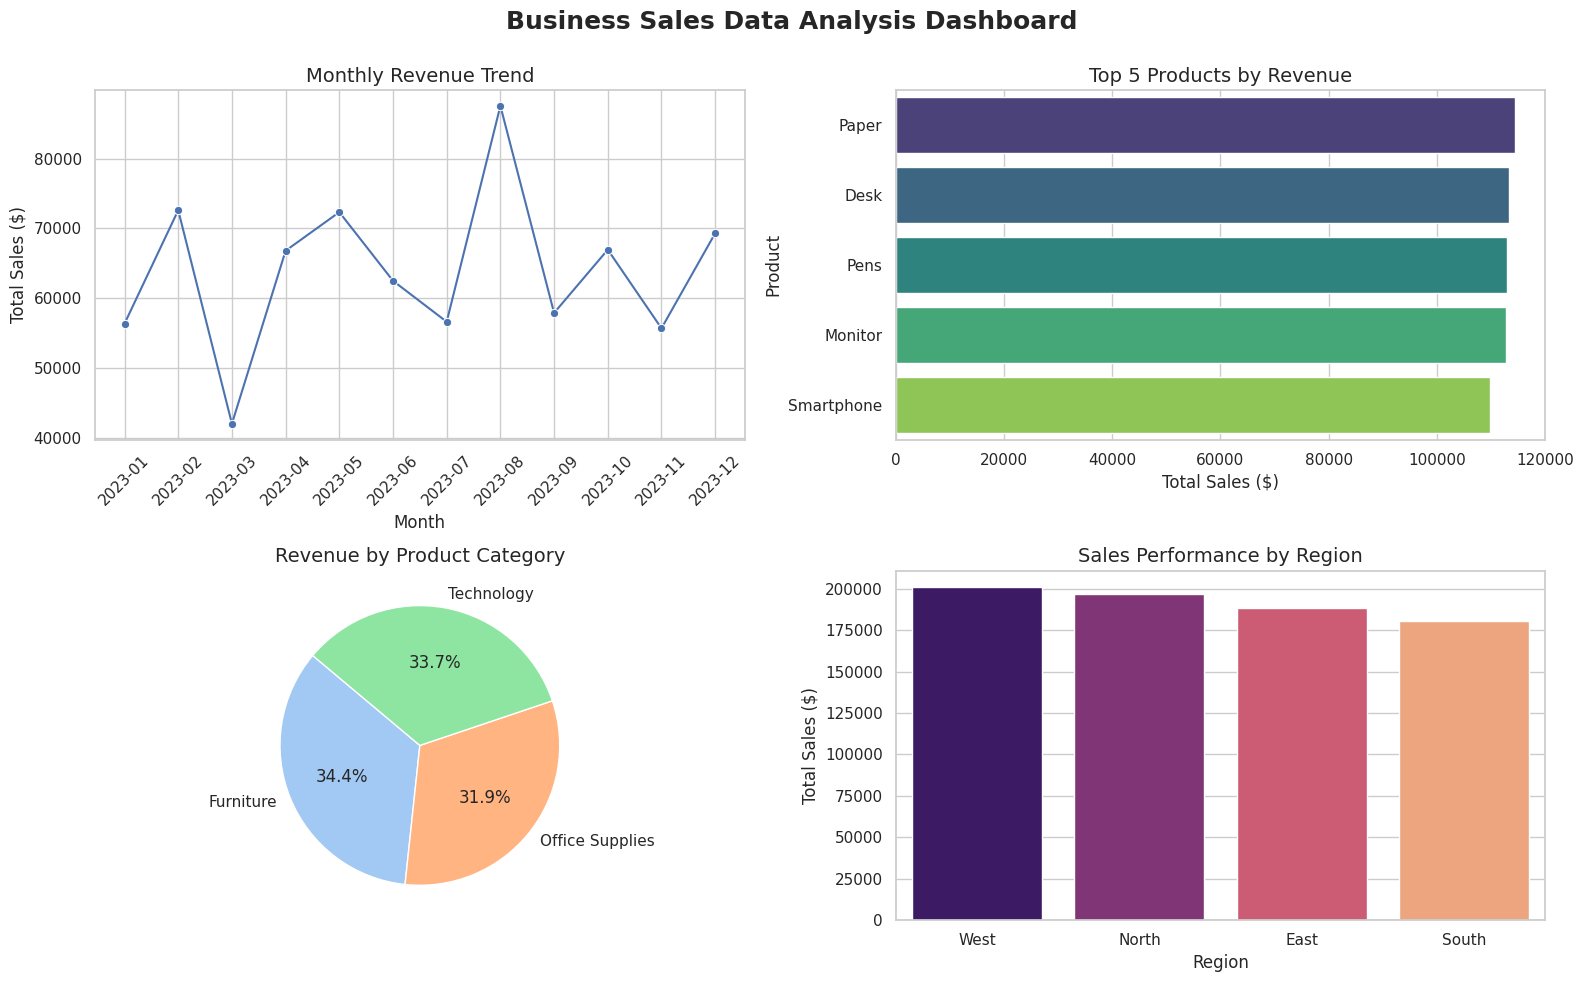


Analysis complete! Dashboard saved as 'sales_dashboard.png'.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta


print("Generating synthetic business sales data...")
np.random.seed(42)
dates = [datetime(2023, 1, 1) + timedelta(days=i) for i in range(365)]
categories = ['Technology', 'Furniture', 'Office Supplies']
products = ['Laptop', 'Smartphone', 'Desk', 'Chair', 'Paper', 'Pens', 'Monitor']
regions = ['North', 'South', 'East', 'West']

data = {
    'Order Date': np.random.choice(dates, 1000),
    'Product': np.random.choice(products, 1000),
    'Category': np.random.choice(categories, 1000),
    'Region': np.random.choice(regions, 1000),
    'Sales': np.random.uniform(10, 1500, 1000),
    'Quantity': np.random.randint(1, 10, 1000),
    'Profit Margin': np.random.uniform(-0.1, 0.4, 1000) # Some negative margins for realism
}
df = pd.DataFrame(data)

df.loc[10:20, 'Sales'] = np.nan
df.loc[50:55, 'Region'] = np.nan

print("\n--- Starting Data Cleaning ---")
print(f"Initial row count: {len(df)}")

df = df.dropna(subset=['Sales', 'Region'])

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Sales'] = df['Sales'].round(2)

df['Profit'] = (df['Sales'] * df['Profit Margin']).round(2)
df['Month'] = df['Order Date'].dt.to_period('M')

print(f"Cleaned row count: {len(df)}")
print("Data cleaning complete!")

print("\n--- Key Performance Indicators (KPIs) ---")
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df)
average_order_value = total_revenue / total_orders
overall_profit_margin = (total_profit / total_revenue) * 100

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value (AOV): ${average_order_value:,.2f}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")

print("\nGenerating visual dashboard...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Business Sales Data Analysis Dashboard', fontsize=18, fontweight='bold')

monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)
sns.lineplot(ax=axes[0, 0], data=monthly_sales, x='Month', y='Sales', marker='o', color='b')
axes[0, 0].set_title('Monthly Revenue Trend', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel('Total Sales ($)')

top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()
sns.barplot(ax=axes[0, 1], data=top_products, x='Sales', y='Product', palette='viridis')
axes[0, 1].set_title('Top 5 Products by Revenue', fontsize=14)
axes[0, 1].set_xlabel('Total Sales ($)')

category_sales = df.groupby('Category')['Sales'].sum()
axes[1, 0].pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 0].set_title('Revenue by Product Category', fontsize=14)

regional_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[1, 1], data=regional_sales, x='Region', y='Sales', palette='magma')
axes[1, 1].set_title('Sales Performance by Region', fontsize=14)
axes[1, 1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig('sales_dashboard.png', dpi=300) # Saves the dashboard as an image
plt.show() # Displays the dashboard

print("\nAnalysis complete! Dashboard saved as 'sales_dashboard.png'.")